# Day 05 — Phase 1: PCA / Dimensionsreduktion

**Dataset:** Wine Quality  
**Goal:** PCA 2D + PCA 3D + explained variance + feature loadings




In [1]:
# ============================================================
# Day 05 - Phase 1
# PCA / Dimensionsreduktion
# Dataset: Wine Quality
# Corrected version: robust CSV separator handling
# ============================================================

import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional: Interactive 3D plot
try:
    import plotly.express as px
    import plotly.io as pio
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False


# ============================================================
# Folder paths
# ============================================================

DAY04_DIR = r"C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_04_Outlier_Anomaly"
AUFGABE_DIR = os.path.dirname(DAY04_DIR)

BASE_DIR = os.path.join(AUFGABE_DIR, "Tag_05_PCA_Dimensionsreduktion")

DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "output")
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
MODELS_DIR = os.path.join(OUTPUT_DIR, "models")
REPORTS_DIR = os.path.join(OUTPUT_DIR, "reports")
NOTEBOOKS_DIR = os.path.join(BASE_DIR, "notebooks")

folders = [
    BASE_DIR,
    DATA_DIR,
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    NOTEBOOKS_DIR
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folder structure is ready.\n")

print("BASE_DIR     :", BASE_DIR)
print("DATA_DIR     :", DATA_DIR)
print("OUTPUT_DIR   :", OUTPUT_DIR)
print("FIGURES_DIR  :", FIGURES_DIR)
print("TABLES_DIR   :", TABLES_DIR)
print("MODELS_DIR   :", MODELS_DIR)
print("REPORTS_DIR  :", REPORTS_DIR)
print("NOTEBOOKS_DIR:", NOTEBOOKS_DIR)
print("Plotly available:", PLOTLY_AVAILABLE)


✅ Folder structure is ready.

BASE_DIR     : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion
DATA_DIR     : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\data
OUTPUT_DIR   : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output
FIGURES_DIR  : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures
TABLES_DIR   : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables
MODELS_DIR   : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\models
REPORTS_DIR  : C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\reports
NOTEBOOKS_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\notebooks
Plotly available: False


In [2]:
# ============================================================
# Load Wine Quality Dataset - Robust Version
# Handles both comma-separated and semicolon-separated files
# ============================================================

local_file = os.path.join(DATA_DIR, "winequality-red.csv")

if os.path.exists(local_file):
    print("✅ Loading local file:")
    print(local_file)

    # First try semicolon separator because original UCI file uses ;
    df = pd.read_csv(local_file, sep=";")

    # If everything is loaded as one column, try comma separator
    if df.shape[1] == 1:
        print("⚠️ Only one column detected with sep=';'. Trying sep=',' ...")
        df = pd.read_csv(local_file, sep=",")

else:
    print("⚠️ Local file not found.")
    print("Trying to load dataset from UCI online source...")

    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
    df = pd.read_csv(url, sep=";")

    # Save local copy using semicolon separator, same as original UCI format
    df.to_csv(local_file, sep=";", index=False)
    print("✅ Dataset downloaded and saved locally:")
    print(local_file)

# Clean column names
# This prevents errors caused by accidental spaces around column names.
df.columns = df.columns.str.strip()

print("\n✅ Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# Safety check: make sure target column exists
if "quality" not in df.columns:
    raise KeyError(
        "Column 'quality' was not found. Please check the CSV separator and column names above."
    )


✅ Loading local file:
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\data\winequality-red.csv
⚠️ Only one column detected with sep=';'. Trying sep=',' ...

✅ Dataset loaded successfully.
Shape: (1599, 12)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# ============================================================
# Basic Data Understanding
# ============================================================

print("First 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset info:")
df.info()

print("\nDescriptive statistics:")
display(df.describe())

print("\nMissing values per column:")
display(df.isna().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

print("\nQuality value counts:")
display(df["quality"].value_counts().sort_index())


First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5



Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000



Missing values per column:


fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


Duplicated rows:
240

Quality value counts:


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [4]:
# ============================================================
# Save basic analysis tables
# ============================================================

# Descriptive statistics
desc_path = os.path.join(TABLES_DIR, "day05_phase1_wine_descriptive_statistics.csv")
df.describe().to_csv(desc_path)

# Missing values
missing_values = df.isna().sum().reset_index()
missing_values.columns = ["column", "missing_count"]

missing_path = os.path.join(TABLES_DIR, "day05_phase1_wine_missing_values.csv")
missing_values.to_csv(missing_path, index=False)

# Quality counts
quality_counts = df["quality"].value_counts().sort_index().reset_index()
quality_counts.columns = ["quality", "count"]

quality_counts_path = os.path.join(TABLES_DIR, "day05_phase1_wine_quality_counts.csv")
quality_counts.to_csv(quality_counts_path, index=False)

print("✅ Saved basic output tables:")
print(desc_path)
print(missing_path)
print(quality_counts_path)


✅ Saved basic output tables:
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_descriptive_statistics.csv
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_missing_values.csv
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_quality_counts.csv


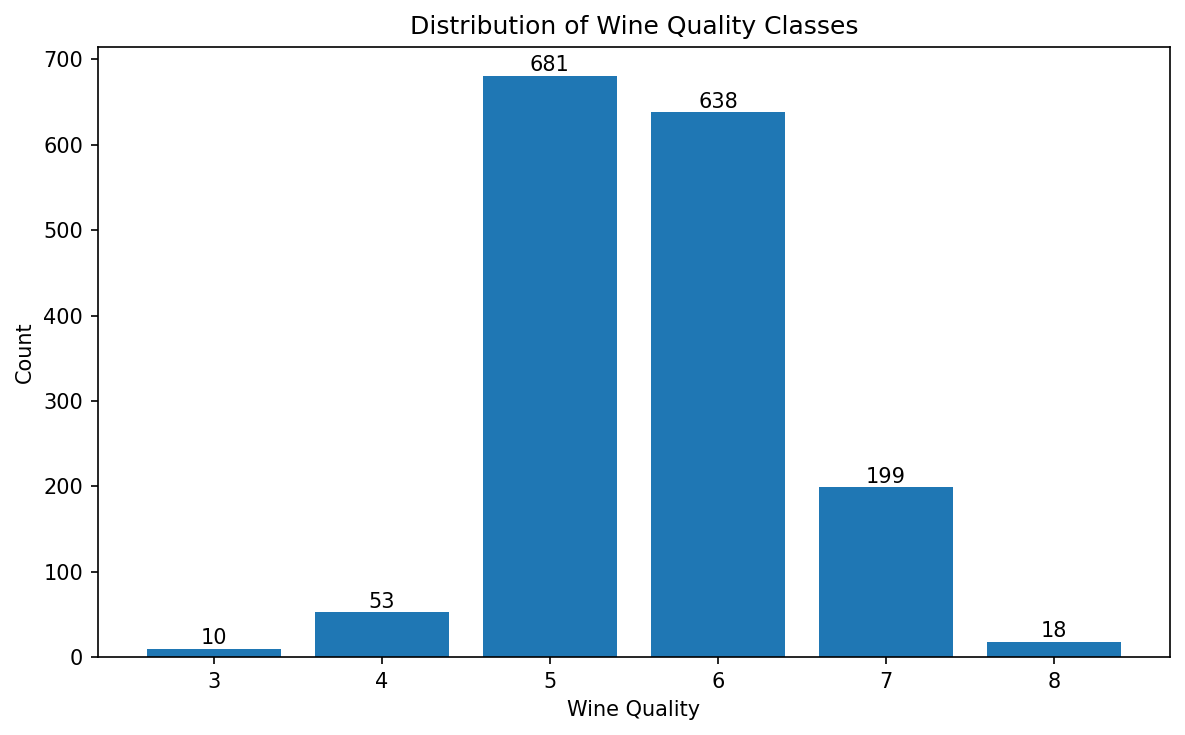

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\day05_phase1_wine_quality_distribution.png


In [5]:
# ============================================================
# Quality distribution plot
# ============================================================

plt.figure(figsize=(8, 5), dpi=150)

quality_counts_sorted = df["quality"].value_counts().sort_index()

plt.bar(
    quality_counts_sorted.index.astype(str),
    quality_counts_sorted.values
)

plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality Classes")

for i, value in enumerate(quality_counts_sorted.values):
    plt.text(i, value + 5, str(value), ha="center")

plt.tight_layout()

quality_plot_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_quality_distribution.png")
plt.savefig(quality_plot_path, dpi=300)
plt.show()

print("✅ Saved:", quality_plot_path)


In [6]:
# ============================================================
# Separate Features X and Target y
# ============================================================

target_column = "quality"

X = df.drop(columns=[target_column])
y = df[target_column]

feature_names = X.columns.tolist()

print("Feature columns:")
print(feature_names)

print("\nTarget column:")
print(target_column)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())


Feature columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target column:
quality

X shape: (1599, 11)
y shape: (1599,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


0    5
1    5
2    5
3    6
4    5
Name: quality, dtype: int64

In [7]:
# ============================================================
# Standardization
# PCA is sensitive to scale.
# Therefore, all features should be standardized:
# mean = 0, standard deviation = 1
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_names
)

print("Scaled X shape:", X_scaled_df.shape)

print("\nMean after scaling:")
display(X_scaled_df.mean().round(4))

print("\nStandard deviation after scaling:")
display(X_scaled_df.std().round(4))

display(X_scaled_df.head())


Scaled X shape: (1599, 11)

Mean after scaling:


fixed acidity           0.0
volatile acidity        0.0
citric acid            -0.0
residual sugar         -0.0
chlorides               0.0
free sulfur dioxide    -0.0
total sulfur dioxide    0.0
density                -0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
dtype: float64


Standard deviation after scaling:


fixed acidity           1.0003
volatile acidity        1.0003
citric acid             1.0003
residual sugar          1.0003
chlorides               1.0003
free sulfur dioxide     1.0003
total sulfur dioxide    1.0003
density                 1.0003
pH                      1.0003
sulphates               1.0003
alcohol                 1.0003
dtype: float64

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


In [8]:
# ============================================================
# Save scaled data
# ============================================================

scaled_data = X_scaled_df.copy()
scaled_data["quality"] = y.values

scaled_data_path = os.path.join(TABLES_DIR, "day05_phase1_wine_scaled_data.csv")
scaled_data.to_csv(scaled_data_path, index=False)

print("✅ Saved scaled data:")
print(scaled_data_path)


✅ Saved scaled data:
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_scaled_data.csv


In [9]:
# ============================================================
# PCA with 2 Components
# ============================================================

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

pcdf_2d = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

pcdf_2d["quality"] = y.values

print("PCA 2D transformed shape:", pcdf_2d.shape)

print("\nExplained variance ratio:")
print(pca_2d.explained_variance_ratio_)

print("\nTotal explained variance by PC1 + PC2:")
print(pca_2d.explained_variance_ratio_.sum())

display(pcdf_2d.head())


PCA 2D transformed shape: (1599, 3)

Explained variance ratio:
[0.28173931 0.1750827 ]

Total explained variance by PC1 + PC2:
0.45682201184294047


,PC1,PC2,quality
0,-1.619530,0.450950,5
1,-0.799170,1.856553,5
2,-0.748479,0.882039,5
3,2.357673,-0.269976,6
4,-1.619530,0.450950,5


In [10]:
# ============================================================
# Save PCA 2D transformed data and explained variance
# ============================================================

pca_2d_data_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_2d_transformed_data.csv")
pcdf_2d.to_csv(pca_2d_data_path, index=False)

explained_variance_2d = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_2d.explained_variance_ratio_,
    "explained_variance_percent": pca_2d.explained_variance_ratio_ * 100
})

explained_variance_2d["cumulative_variance_ratio"] = explained_variance_2d["explained_variance_ratio"].cumsum()
explained_variance_2d["cumulative_variance_percent"] = explained_variance_2d["cumulative_variance_ratio"] * 100

explained_2d_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_2d_explained_variance.csv")
explained_variance_2d.to_csv(explained_2d_path, index=False)

display(explained_variance_2d)

print("✅ Saved:")
print(pca_2d_data_path)
print(explained_2d_path)


,component,explained_variance_ratio,explained_variance_percent,cumulative_variance_ratio,cumulative_variance_percent
0,PC1,0.281739,28.173931,0.281739,28.173931
1,PC2,0.175083,17.508270,0.456822,45.682201


✅ Saved:
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_2d_transformed_data.csv
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_2d_explained_variance.csv


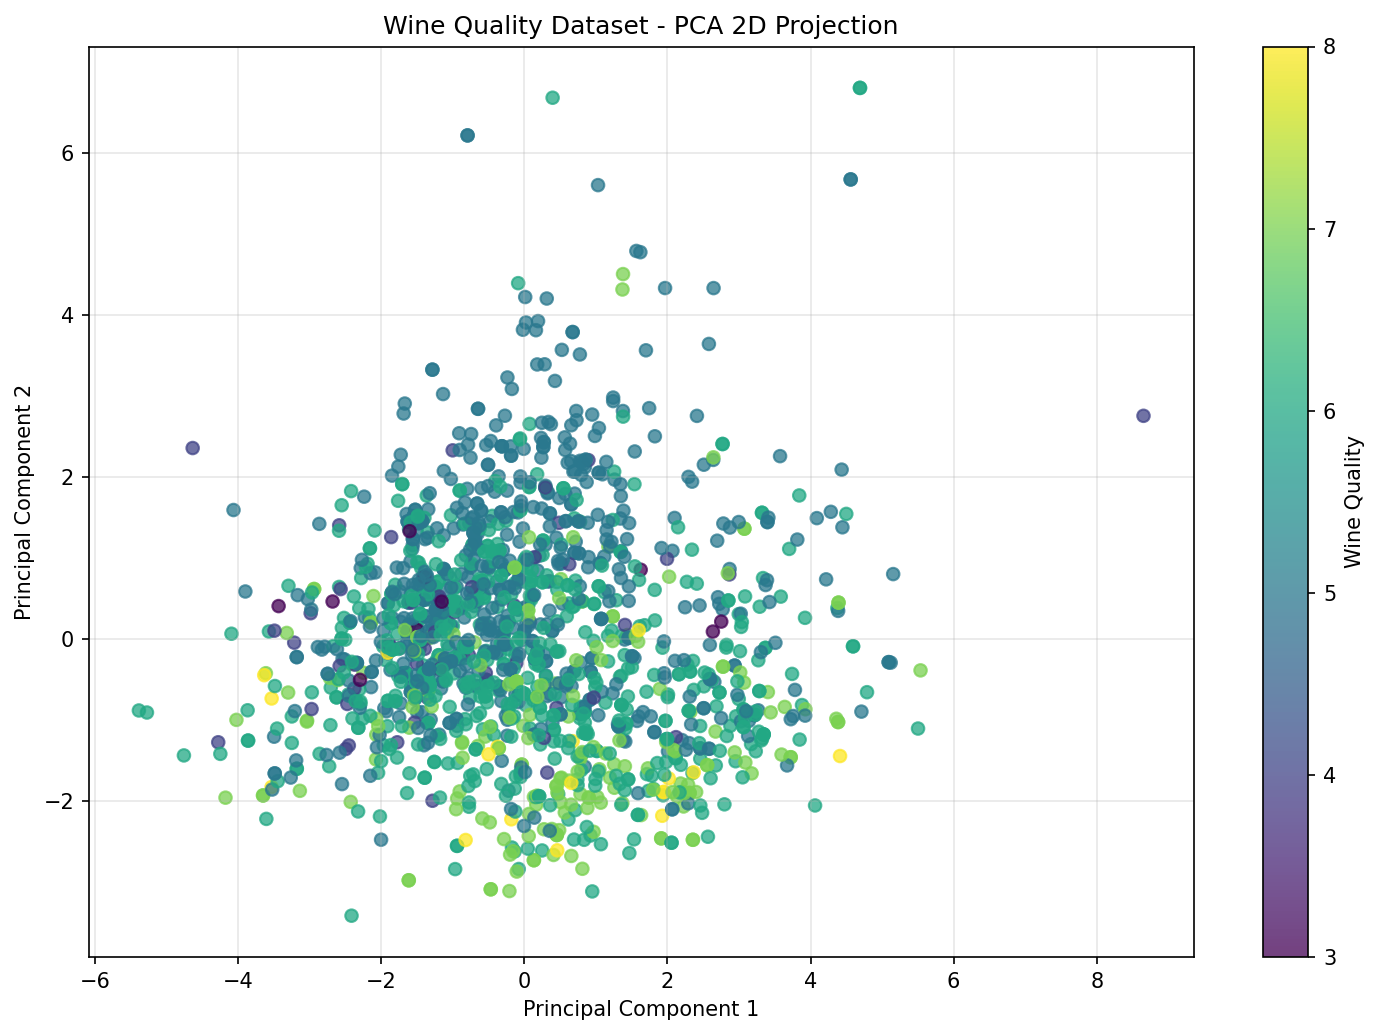

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\day05_phase1_wine_pca_2d_scatterplot.png


In [11]:
# ============================================================
# 2D PCA Scatterplot
# ============================================================

plt.figure(figsize=(10, 7), dpi=150)

scatter = plt.scatter(
    pcdf_2d["PC1"],
    pcdf_2d["PC2"],
    c=pcdf_2d["quality"],
    alpha=0.75
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Quality Dataset - PCA 2D Projection")

cbar = plt.colorbar(scatter)
cbar.set_label("Wine Quality")

plt.grid(True, alpha=0.3)
plt.tight_layout()

pca_2d_plot_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_pca_2d_scatterplot.png")
plt.savefig(pca_2d_plot_path, dpi=300)
plt.show()

print("✅ Saved:", pca_2d_plot_path)


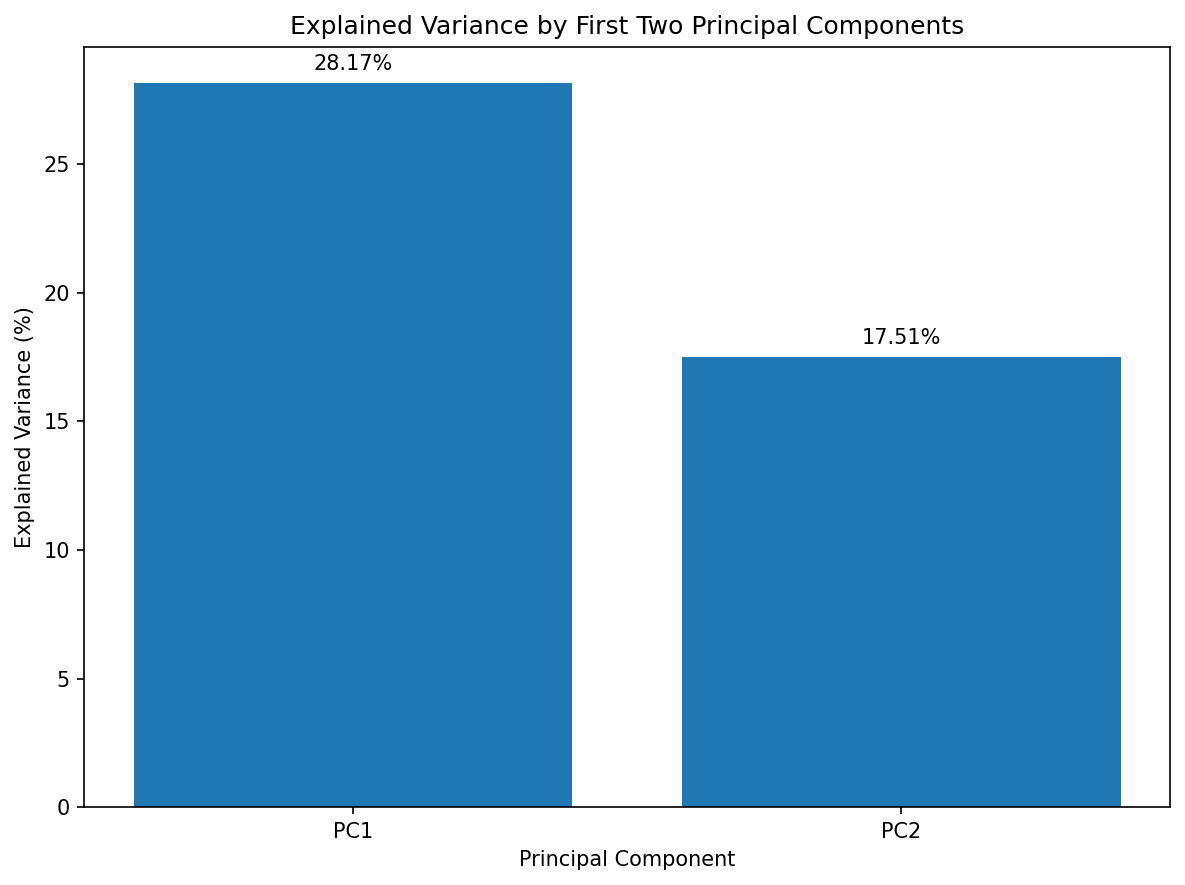

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\day05_phase1_wine_pca_2d_explained_variance_barplot.png


In [12]:
# ============================================================
# Explained Variance Barplot for PC1 and PC2
# ============================================================

plt.figure(figsize=(8, 6), dpi=150)

plt.bar(
    explained_variance_2d["component"],
    explained_variance_2d["explained_variance_percent"]
)

plt.ylabel("Explained Variance (%)")
plt.xlabel("Principal Component")
plt.title("Explained Variance by First Two Principal Components")

for i, value in enumerate(explained_variance_2d["explained_variance_percent"]):
    plt.text(i, value + 0.5, f"{value:.2f}%", ha="center")

plt.tight_layout()

variance_barplot_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_pca_2d_explained_variance_barplot.png")
plt.savefig(variance_barplot_path, dpi=300)
plt.show()

print("✅ Saved:", variance_barplot_path)


In [13]:
# ============================================================
# PCA with 3 Components
# ============================================================

pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_scaled)

pcdf_3d = pd.DataFrame(
    X_pca_3d,
    columns=["PC1", "PC2", "PC3"]
)

pcdf_3d["quality"] = y.values

print("PCA 3D transformed shape:", pcdf_3d.shape)

print("\nExplained variance ratio:")
print(pca_3d.explained_variance_ratio_)

print("\nTotal explained variance by PC1 + PC2 + PC3:")
print(pca_3d.explained_variance_ratio_.sum())

display(pcdf_3d.head())


PCA 3D transformed shape: (1599, 4)

Explained variance ratio:
[0.28173931 0.1750827  0.1409585 ]

Total explained variance by PC1 + PC2 + PC3:
0.5977805108224622


,PC1,PC2,PC3,quality
0,-1.619530,0.450950,-1.774454,5
1,-0.799170,1.856553,-0.911690,5
2,-0.748479,0.882039,-1.171394,5
3,2.357673,-0.269976,0.243489,6
4,-1.619530,0.450950,-1.774454,5


In [14]:
# ============================================================
# Save PCA 3D transformed data and explained variance
# ============================================================

pca_3d_data_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_3d_transformed_data.csv")
pcdf_3d.to_csv(pca_3d_data_path, index=False)

explained_variance_3d = pd.DataFrame({
    "component": ["PC1", "PC2", "PC3"],
    "explained_variance_ratio": pca_3d.explained_variance_ratio_,
    "explained_variance_percent": pca_3d.explained_variance_ratio_ * 100
})

explained_variance_3d["cumulative_variance_ratio"] = explained_variance_3d["explained_variance_ratio"].cumsum()
explained_variance_3d["cumulative_variance_percent"] = explained_variance_3d["cumulative_variance_ratio"] * 100

explained_3d_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_3d_explained_variance.csv")
explained_variance_3d.to_csv(explained_3d_path, index=False)

display(explained_variance_3d)

print("✅ Saved:")
print(pca_3d_data_path)
print(explained_3d_path)


,component,explained_variance_ratio,explained_variance_percent,cumulative_variance_ratio,cumulative_variance_percent
0,PC1,0.281739,28.173931,0.281739,28.173931
1,PC2,0.175083,17.508270,0.456822,45.682201
2,PC3,0.140958,14.095850,0.597781,59.778051


✅ Saved:
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_3d_transformed_data.csv
C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_3d_explained_variance.csv


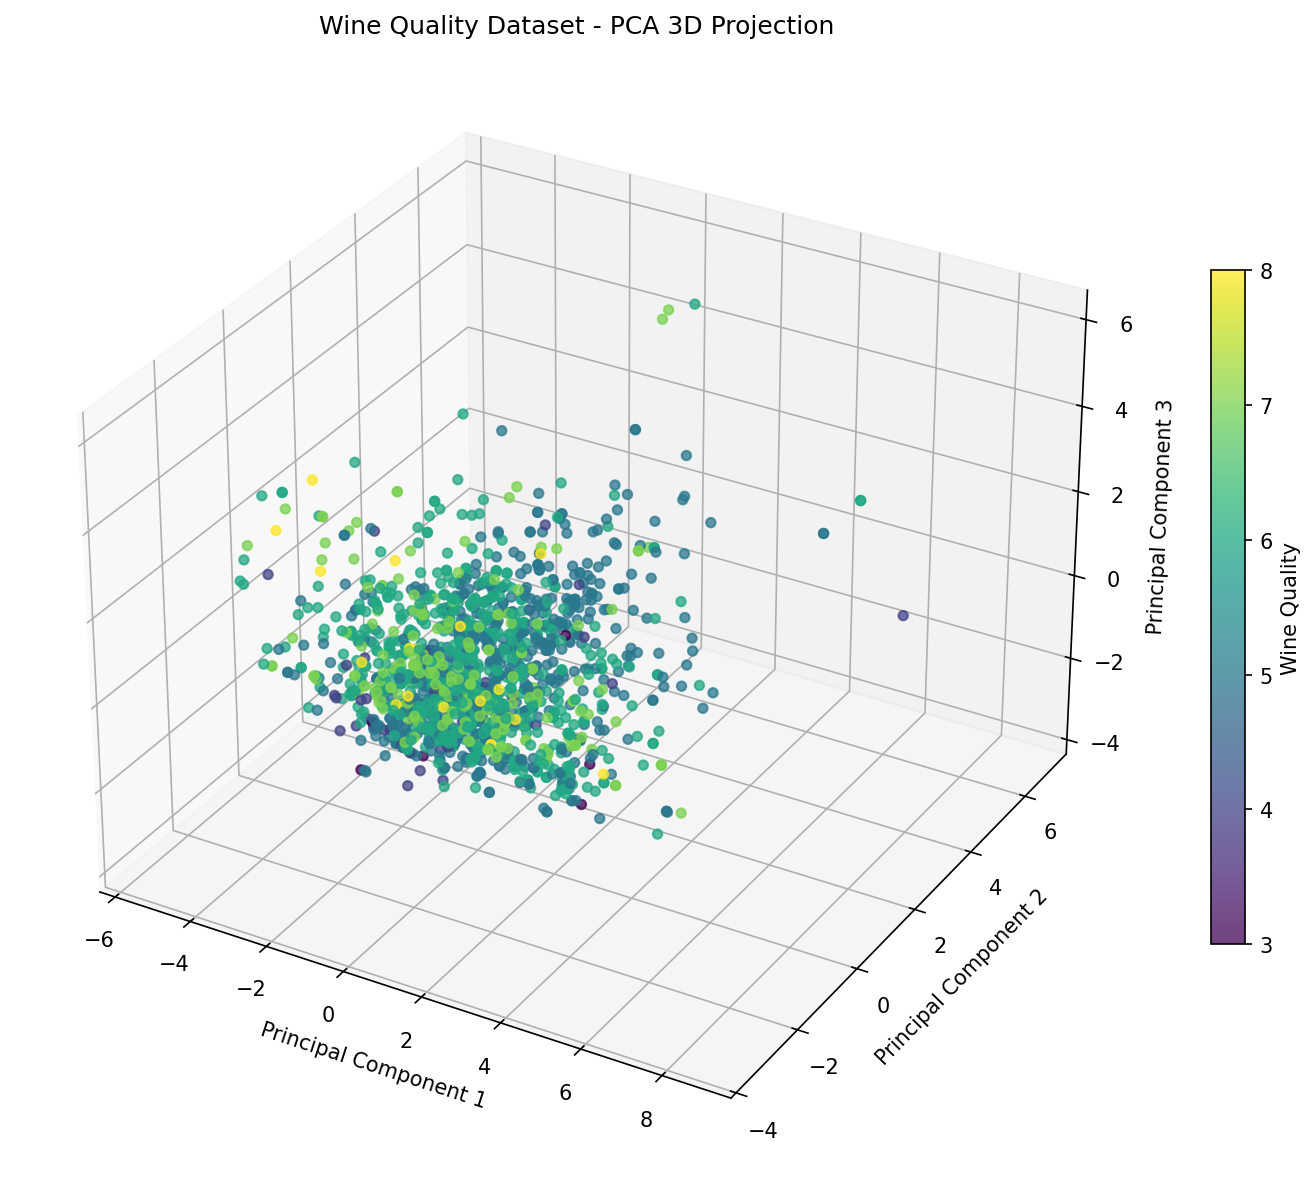

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\day05_phase1_wine_pca_3d_scatterplot_static.png


In [15]:
# ============================================================
# Static 3D PCA Plot with Matplotlib
# ============================================================

fig = plt.figure(figsize=(10, 8), dpi=150)
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    pcdf_3d["PC1"],
    pcdf_3d["PC2"],
    pcdf_3d["PC3"],
    c=pcdf_3d["quality"],
    alpha=0.75
)

ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
ax.set_title("Wine Quality Dataset - PCA 3D Projection")

cbar = fig.colorbar(scatter, ax=ax, shrink=0.6)
cbar.set_label("Wine Quality")

plt.tight_layout()

pca_3d_plot_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_pca_3d_scatterplot_static.png")
plt.savefig(pca_3d_plot_path, dpi=300)
plt.show()

print("✅ Saved:", pca_3d_plot_path)


In [16]:
# ============================================================
# Interactive 3D PCA Plot with Plotly
# This plot can be rotated.
# ============================================================

if PLOTLY_AVAILABLE:
    pio.renderers.default = "notebook"

    fig = px.scatter_3d(
        pcdf_3d,
        x="PC1",
        y="PC2",
        z="PC3",
        color=pcdf_3d["quality"].astype(str),
        title="Wine Quality Dataset - Interactive PCA 3D Projection",
        width=1000,
        height=800
    )

    fig.update_traces(marker=dict(size=4))
    fig.show()

    html_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_pca_3d_interactive.html")
    fig.write_html(html_path)

    print("✅ Saved:", html_path)

else:
    print("⚠️ Plotly is not installed.")
    print("Install it with:")
    print("pip install plotly")


⚠️ Plotly is not installed.
Install it with:
pip install plotly


In [17]:
# ============================================================
# PCA Loadings
# Loadings show how strongly each original feature contributes
# to PC1 and PC2.
# ============================================================

loadings_2d = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1_loading", "PC2_loading"],
    index=feature_names
)

loadings_2d["abs_PC1_loading"] = loadings_2d["PC1_loading"].abs()
loadings_2d["abs_PC2_loading"] = loadings_2d["PC2_loading"].abs()

print("Features sorted by contribution to PC1:")
display(loadings_2d.sort_values("abs_PC1_loading", ascending=False))

print("Features sorted by contribution to PC2:")
display(loadings_2d.sort_values("abs_PC2_loading", ascending=False))

loadings_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_2d_loadings.csv")
loadings_2d.to_csv(loadings_path)

print("✅ Saved:", loadings_path)


Features sorted by contribution to PC1:


,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
fixed acidity,0.489314,-0.110503,0.489314,0.110503
citric acid,0.463632,-0.151791,0.463632,0.151791
pH,-0.438520,0.006711,0.438520,0.006711
density,0.395353,0.233575,0.395353,0.233575
sulphates,0.242921,-0.037554,0.242921,0.037554
volatile acidity,-0.238584,0.274930,0.238584,0.274930
chlorides,0.212247,0.148052,0.212247,0.148052
residual sugar,0.146107,0.272080,0.146107,0.272080
alcohol,-0.113232,-0.386181,0.113232,0.386181
free sulfur dioxide,-0.036158,0.513567,0.036158,0.513567


Features sorted by contribution to PC2:


,PC1_loading,PC2_loading,abs_PC1_loading,abs_PC2_loading
total sulfur dioxide,0.023575,0.569487,0.023575,0.569487
free sulfur dioxide,-0.036158,0.513567,0.036158,0.513567
alcohol,-0.113232,-0.386181,0.113232,0.386181
volatile acidity,-0.238584,0.274930,0.238584,0.274930
residual sugar,0.146107,0.272080,0.146107,0.272080
density,0.395353,0.233575,0.395353,0.233575
citric acid,0.463632,-0.151791,0.463632,0.151791
chlorides,0.212247,0.148052,0.212247,0.148052
fixed acidity,0.489314,-0.110503,0.489314,0.110503
sulphates,0.242921,-0.037554,0.242921,0.037554


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_2d_loadings.csv


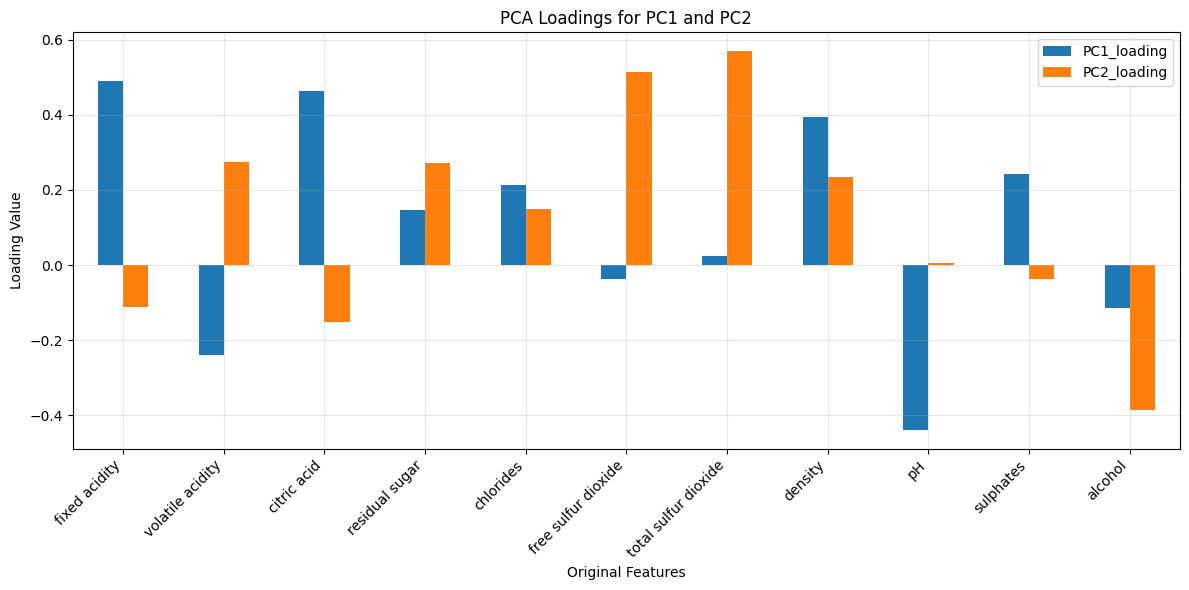

✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\figures\day05_phase1_wine_pca_loadings_barplot.png


In [18]:
# ============================================================
# Visualize Feature Loadings for PC1 and PC2
# ============================================================

loadings_plot_df = loadings_2d[["PC1_loading", "PC2_loading"]]

ax = loadings_plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("PCA Loadings for PC1 and PC2")
plt.xlabel("Original Features")
plt.ylabel("Loading Value")
plt.xticks(rotation=45, ha="right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

loadings_plot_path = os.path.join(FIGURES_DIR, "day05_phase1_wine_pca_loadings_barplot.png")
plt.savefig(loadings_plot_path, dpi=300)
plt.show()

print("✅ Saved:", loadings_plot_path)


In [19]:
# ============================================================
# Automatic Summary for Interpretation
# ============================================================

pc1_var = explained_variance_2d.loc[0, "explained_variance_percent"]
pc2_var = explained_variance_2d.loc[1, "explained_variance_percent"]
total_2d_var = explained_variance_2d["explained_variance_percent"].sum()

total_3d_var = explained_variance_3d["explained_variance_percent"].sum()

top_pc1_features = (
    loadings_2d
    .sort_values("abs_PC1_loading", ascending=False)
    .head(5)
    .index
    .tolist()
)

top_pc2_features = (
    loadings_2d
    .sort_values("abs_PC2_loading", ascending=False)
    .head(5)
    .index
    .tolist()
)

summary = {
    "Number of rows": df.shape[0],
    "Number of original features": X.shape[1],
    "Target column": target_column,
    "PC1 explained variance (%)": round(pc1_var, 2),
    "PC2 explained variance (%)": round(pc2_var, 2),
    "Total 2D explained variance (%)": round(total_2d_var, 2),
    "Total 3D explained variance (%)": round(total_3d_var, 2),
    "Top PC1 contributing features": ", ".join(top_pc1_features),
    "Top PC2 contributing features": ", ".join(top_pc2_features)
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["item", "value"]
)

display(summary_df)

summary_path = os.path.join(TABLES_DIR, "day05_phase1_wine_pca_summary.csv")
summary_df.to_csv(summary_path, index=False)

print("✅ Saved:", summary_path)


,item,value
0,Number of rows,1599
1,Number of original features,11
2,Target column,quality
3,PC1 explained variance (%),28.17
4,PC2 explained variance (%),17.51
5,Total 2D explained variance (%),45.68
6,Total 3D explained variance (%),59.78
7,Top PC1 contributing features,"fixed acidity, citric acid, pH, density, sulph..."
8,Top PC2 contributing features,"total sulfur dioxide, free sulfur dioxide, alc..."


✅ Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\Tag_05_PCA_Dimensionsreduktion\output\tables\day05_phase1_wine_pca_summary.csv


In [20]:
# ============================================================
# Final Check: List all created output files
# ============================================================

print("✅ Files created in TABLES_DIR:")
for file in os.listdir(TABLES_DIR):
    print(" -", file)

print("\n✅ Files created in FIGURES_DIR:")
for file in os.listdir(FIGURES_DIR):
    print(" -", file)


✅ Files created in TABLES_DIR:
 - day05_phase1_wine_descriptive_statistics.csv
 - day05_phase1_wine_missing_values.csv
 - day05_phase1_wine_pca_2d_explained_variance.csv
 - day05_phase1_wine_pca_2d_loadings.csv
 - day05_phase1_wine_pca_2d_transformed_data.csv
 - day05_phase1_wine_pca_3d_explained_variance.csv
 - day05_phase1_wine_pca_3d_transformed_data.csv
 - day05_phase1_wine_pca_summary.csv
 - day05_phase1_wine_quality_counts.csv
 - day05_phase1_wine_scaled_data.csv

✅ Files created in FIGURES_DIR:
 - day05_phase1_wine_pca_2d_explained_variance_barplot.png
 - day05_phase1_wine_pca_2d_scatterplot.png
 - day05_phase1_wine_pca_3d_scatterplot_static.png
 - day05_phase1_wine_pca_loadings_barplot.png
 - day05_phase1_wine_quality_distribution.png
